TASK 1

In [ ]:
!pip install h2o

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.0/266.0 MB 5.0 MB/s eta 0:00:00


In [ ]:
import sys, os, os.path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pickle

import h2o
from h2o.automl import H2OAutoML

h2o.init(
    nthreads=-1,     # number of threads when launching a new H2O server
    max_mem_size=12  # in gigabytes
)

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.17" 2025-10-21; OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-122.04); OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-122.04, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpn1uyc171
  JVM stdout: /tmp/tmpn1uyc171/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpn1uyc171/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,1 month and 14 days
H2O_cluster_name:,H2O_from_python_unknownUser_n9g34f
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,12 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [ ]:
from h2o import *

In [ ]:
train_df = pd.read_csv('/content/customer_churn_dataset-training-master.csv')
test_df = pd.read_csv('/content/customer_churn_dataset-testing-master.csv')

In [ ]:
print('train_df cols:', list(train_df.columns))
print('test_df cols: ', list(test_df.columns))
train_df.head()

train_df cols: ['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']
test_df cols:  ['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [ ]:
train_df.dtypes

,0
CustomerID,float64
Age,float64
Gender,object
Tenure,float64
Usage Frequency,float64
Support Calls,float64
Payment Delay,float64
Subscription Type,object
Contract Length,object
Total Spend,float64


In [ ]:
print('Null values in training data:')
print(train_df.isnull().sum())
print('\nNull values in testing data:')
print(test_df.isnull().sum())

Null values in training data:
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

Null values in testing data:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [ ]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,30 mins 59 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,1 month and 14 days
H2O_cluster_name:,H2O_from_python_unknownUser_n9g34f
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,11.97 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [ ]:
train=h2o.import_file('/content/customer_churn_dataset-training-master.csv')
test=h2o.import_file('/content/customer_churn_dataset-testing-master.csv')

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [ ]:
y="Churn"
x =train.columns
x.remove(y)
x.remove('CustomerID')

In [ ]:
for col in ['Gender', 'Subscription Type', 'Contract Length']:
    train[col] = train[col].asfactor()
    test[col] = test[col].asfactor()

train[y] = train[y].asfactor()

In [ ]:
aml = H2OAutoML(
    max_models=20,
    seed=1,
    nfolds=5,
    balance_classes=True,
    max_runtime_secs=300
)
aml.train(x=x, y=y, training_frame=train)

AutoML progress: |
09:58:15.536: XGBoost_1_AutoML_3_20260108_95814 [XGBoost def_2] failed: water.exceptions.H2OModelBuilderIllegalArgumentException: Illegal argument(s) for XGBoost model: XGBoost_1_AutoML_3_20260108_95814_cv_1.  Details: ERRR on field: _response_column: Response contains missing values (NAs) - not supported by XGBoost.


███████████████████████████████████████████████████████████████| (done) 100%


Model Details
=============
H2OGeneralizedLinearEstimator : Generalized Linear Modeling
Model Key: GLM_1_AutoML_3_20260108_95814


GLM Model: summary
    family    link    regularization               lambda_search                                                                    number_of_predictors_total    number_of_active_predictors    number_of_iterations    training_frame
--  --------  ------  ---------------------------  -------------------------------------------------------------------------------  ----------------------------  -----------------------------  ----------------------  ----------------------------------------------
    binomial  logit   Ridge ( lambda = 2.845E-5 )  nlambda = 30, lambda.max = 28.453, lambda.min = 2.845E-5, lambda.1se = 1.188E-4  15                            15                             59                      AutoML_3_20260108_95814_training_py_7_sid_a47a

ModelMetricsBinomialGLM: glm
** Reported on train data. **

MSE: 0.07557740294801965
RMSE: 0.27491344628449815
LogLoss: 0.2438629063445517
AUC: 0.9595833298992437
AUCPR: 0.9743744621081714
Gini: 0.9191666597984873
Null degrees of freedom: 440831
Residual degrees of freedom: 440816
Null deviance: 603157.9728139983
Residual deviance: 215005.14545936283
AIC: 215037.14545936283

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.5003636364590422
       0       1       Error    Rate
-----  ------  ------  -------  ------------------
0      172826  18007   0.0944   (18007.0/190833.0)
1      28048   221951  0.1122   (28048.0/249999.0)
Total  200874  239958  0.1045   (46055.0/440832.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.500364     0.906002  181
max f2                       0.207688     0.920139  286
max f0point5                 0.776564     0.939907  93
max accuracy                 0.587294     0.896165  154
max precision                0.999934     1         0
max recall                   0.00382019   1         398
max specificity              0.999934     1         0
max absolute_mcc             0.607385     0.794949  148
max min_per_class_accuracy   0.472233     0.894054  190
max mean_per_class_accuracy  0.62749      0.901017  141
max tns                      0.999934     190833    0
max fns                      0.999934     170348    0
max fps                      0.00210642   190833    399
max tps                      0.00382019   249999    398
max tnr                      0.999934     1         0
max fnr                      0.999934     0.681395  0
max fpr                      0.00210642   1         399
max tpr                      0.00382019   1         398

Gains/Lift Table: Avg response rate: 56.71 %, avg score: 56.71 %
group    cumulative_data_fraction    lower_threshold    lift       cumulative_lift    response_rate    score      cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain      cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  ---------  -----------------  ---------------  ---------  --------------------------  ------------------  --------------  -------------------------  --------  -----------------  --------------------
1        0.0100015                   1                  1.76334    1.76334            1                1          1                           1                   0.0176361       0.0176361                  76.3335   76.3335            0.0176361
2        0.0200008                   1                  1.76334    1.76334            1                1          1                           1                   0.0176321       0.0352681                  76.3335   76.3335            0.0352681
3        0.0300001                   0.999999           1.76334    1.76334            1                1          1                           1                   

In [ ]:
lb = aml.leaderboard
lb.head(rows=lb.nrows)

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
GLM_1_AutoML_3_20260108_95814,0.959579,0.243922,0.97437,0.104168,0.27493,0.0755863


In [ ]:
best_model = aml.leader

preds = best_model.predict(test)

performance = best_model.model_performance(test)
print(performance)

glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
ModelMetricsBinomialGLM: glm
** Reported on test data. **

MSE: 0.383156880696942
RMSE: 0.6189966726057111
LogLoss: 2.5814020435899456
AUC: 0.693126744754832
AUCPR: 0.6091576018318886
Gini: 0.3862534895096641
Null degrees of freedom: 64373
Residual degrees of freedom: 64358
Null deviance: 91326.44311831871
Residual deviance: 332350.35030811833
AIC: 332382.35030811833

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.8737019516089933
       0      1      Error    Rate
-----  -----  -----  -------  -----------------
0      12102  21779  0.6428   (21779.0/33881.0)
1      1964   28529  0.0644   (1964.0/30493.0)
Total  14066  50308  0.3688   (23743.0/64374.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.873702     0.706155  98
ma

TASK 2


In [2]:
!pip install autokeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 7.8 MB/s eta 0:00:00


In [3]:
import autokeras as ak
from tensorflow.keras.datasets import mnist

In [4]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")

clf = ak.ImageClassifier(overwrite=True, max_trials=1)

print("Starting model search...")
clf.fit(x_train, y_train, epochs=2)

print("Evaluating the best model...")
accuracy = clf.evaluate(x_test, y_test)
print(f"Accuracy: {accuracy}")

best_model = clf.export_model()
best_model.summary()

Trial 1 Complete [00h 04m 14s]
val_loss: 0.05186350643634796

Best val_loss So Far: 0.05186350643634796
Total elapsed time: 00h 04m 14s
Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 138s 73ms/step - accuracy: 0.9041 - loss: 0.3053
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 133s 71ms/step - accuracy: 0.9769 - loss: 0.0756
Evaluating the best model...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9836 - loss: 0.0495
Accuracy: [0.03990998864173889, 0.9873999953269958]


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_to_float32 (CastToFloat32) │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ expand_last_dim (ExpandLastDim) │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 28, 28, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        92,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head_1 (Softmax) │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,989 (433.55 KB)

 Trainable params: 110,986 (433.54 KB)

 Non-trainable params: 3 (16.00 B)

TASK 3

In [ ]:
!pip install autogluon
!pip install tpot

In [ ]:
from autogluon.tabular import TabularDataset, TabularPredictor

train_data = TabularDataset('https://autogluon.s3.amazonaws.com/datasets/Inc/train.csv')
label = 'class'

predictor = TabularPredictor(label=label).fit(train_data, presets='best_quality')

test_data = TabularDataset('https://autogluon.s3.amazonaws.com/datasets/Inc/test.csv')
performance = predictor.evaluate(test_data)
print(f"AutoGluon Performance: {performance}")

In [ ]:
from tpot import TPOTClassifier
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, train_size=0.75)

tpot = TPOTClassifier(generations=2, population_size=20, random_state=42)

tpot.fit(X_train, y_train)
print(f"TPOT Score: {tpot.score(X_test, y_test)}")

tpot.export('best_pipeline.py')


TASK 4


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 705ms/step
Zero-Shot Accuracy (TF-IDF Simple): 6.00%


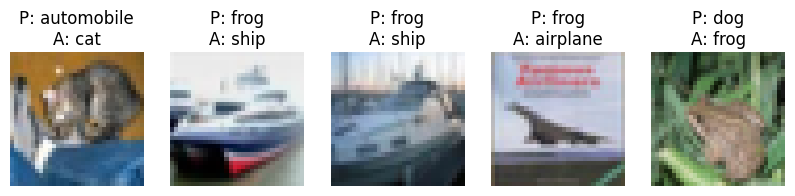

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
subset_size = 100
images, labels = x_test[:subset_size], y_test[:subset_size].flatten()

base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(32, 32, 3))

processed_imgs = preprocess_input(images.astype('float32'))
image_features = base_model.predict(processed_imgs)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

descriptions = [
    "a flying vehicle with wings", "a road vehicle with four wheels",
    "a feathered animal that flies", "a small furry pet that meows",
    "a forest animal with antlers", "a loyal pet that barks",
    "a green amphibian that jumps", "a large animal for riding",
    "a large boat on water", "a large vehicle for transport"
]
vectorizer = TfidfVectorizer()
label_embeddings = vectorizer.fit_transform(descriptions).toarray()

from sklearn.decomposition import PCA
pca = PCA(n_components=label_embeddings.shape[1])
image_features_reduced = pca.fit_transform(image_features)

similarity_matrix = cosine_similarity(image_features_reduced, label_embeddings)

predictions = np.argmax(similarity_matrix, axis=1)

acc = accuracy_score(labels, predictions)
print(f"Zero-Shot Accuracy (TF-IDF Simple): {acc * 100:.2f}%")

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i])
    plt.title(f"P: {class_names[predictions[i]]}\nA: {class_names[labels[i]]}")
    plt.axis('off')
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 715ms/step
Zero-Shot Accuracy (TF-IDF Simple): 15.00%


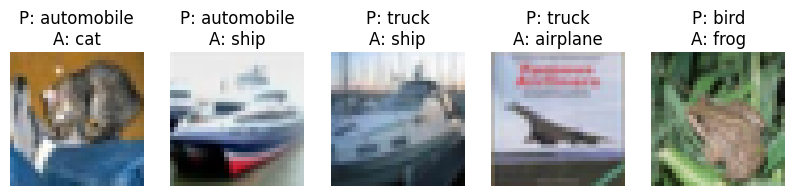

Zero-shot components saved successfully!
Please enter the path to your image: /content/zebra.jpg
------------------------------
Prediction: DOG
Similarity Score: 0.4647
------------------------------


In [13]:
import pickle
import joblib
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
subset_size = 100
images, labels = x_test[:subset_size], y_test[:subset_size].flatten()
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(32, 32, 3))
processed_imgs = preprocess_input(images.astype('float32'))
image_features = base_model.predict(processed_imgs)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

descriptions = [
       """airplane aircraft jet plane fighter commercial airliner aviation flying
          sky wings propeller cockpit fuselage tail flight aviation vehicle airborne
          pilot passenger cargo military civilian transport airbus boeing metal fast""",
     """automobile car sedan vehicle road street driving motor engine wheels
          tire transport highway automotive coupe hatchback convertible SUV
          passenger commercial racing sports luxury compact family transportation metal""",
     """bird avian flying feathers wings beak animal creature wildlife sparrow
          eagle hawk pigeon dove robin cardinal finch flight sky tree perch nest
          singing chirping small colorful nature outdoor wild pet organic""",
     """cat feline kitten pet domestic animal mammal furry whiskers meow purr
          tabby persian siamese calico orange black white striped spotted ears
          tail paws claws hunter playful cute adorable companion house organic""",
     """deer animal wildlife mammal antlers forest woodland buck doe fawn
          herbivore nature wild brown tan white spots running jumping graceful
          hunting game venison elk reindeer moose caribou outdoor organic""",
     """dog canine puppy pet domestic animal mammal furry tail bark woof
          retriever terrier bulldog poodle shepherd husky companion loyal
          friendly playful hunting guard working service therapy family organic""",
     """frog amphibian animal creature green wet water pond lake swamp marsh
          jumping hopping croaking ribbit tadpole legs webbed tropical rainforest
          slimy smooth skin eyes bulging small reptile toad organic living""",
     """horse equine stallion mare pony animal mammal riding galloping trotting
          racing farm ranch stable brown black white chestnut mane tail hooves
          saddle bridle equestrian western cowboy wild mustang thoroughbred organic""",
     """ship boat vessel maritime ocean sea water sailing cruise cargo container
          freight navy military warship battleship destroyer cruiser yacht sailboat
          speedboat hull deck mast anchor port harbor dock naval marine metal""",
     """truck vehicle transportation cargo delivery pickup heavy large commercial
          freight hauling semi trailer lorry flatbed dump moving van wheels diesel
          road highway transport highway transport logistics shipping construction industrial metal"""
]

vectorizer = TfidfVectorizer()
label_embeddings_original = vectorizer.fit_transform(descriptions).toarray()

from sklearn.decomposition import PCA

# Determine a common dimensionality for PCA
# image_features has 100 samples. label_embeddings_original has 10 samples (descriptions) and 233 features.
# PCA on image_features can have max 100 components.
# PCA on label_embeddings_original can have max 10 components.
# To compare them with cosine_similarity, they must have the same number of features.
# The common bottleneck is 10 components.
n_components_common = min(image_features.shape[0], label_embeddings_original.shape[0])

# Apply PCA to image_features
pca_image = PCA(n_components=n_components_common)
image_features_reduced = pca_image.fit_transform(image_features)

# Apply PCA to label_embeddings_original
pca_label = PCA(n_components=n_components_common)
label_embeddings_reduced = pca_label.fit_transform(label_embeddings_original)

similarity_matrix = cosine_similarity(image_features_reduced, label_embeddings_reduced)
predictions = np.argmax(similarity_matrix, axis=1)
acc = accuracy_score(labels, predictions)
print(f"Zero-Shot Accuracy (TF-IDF Simple): {acc * 100:.2f}%")


plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i])
    plt.title(f"P: {class_names[predictions[i]]}\nA: {class_names[labels[i]]}")
    plt.axis('off')
plt.show()

# Save both PCA models and the reduced label embeddings
joblib.dump(pca_image, 'zsl_pca_image.joblib')
joblib.dump(pca_label, 'zsl_pca_label.joblib')
joblib.dump(vectorizer, 'zsl_tfidf.joblib')
np.save('label_embeddings_reduced.npy', label_embeddings_reduced)
with open('class_names.pkl', 'wb') as f:
    pickle.dump(class_names, f)

print("Zero-shot components saved successfully!")

import numpy as np
import tensorflow as tf
import joblib
import pickle
import os
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from sklearn.metrics.pairwise import cosine_similarity

def run_prediction():
    try:
        # Load both PCA models
        pca_image = joblib.load('zsl_pca_image.joblib')
        pca_label = joblib.load('zsl_pca_label.joblib') # Loaded but not used if new descriptions aren't processed
        vectorizer = joblib.load('zsl_tfidf.joblib') # Only needed if new descriptions are given
        label_embeddings_reduced = np.load('label_embeddings_reduced.npy')
        with open('class_names.pkl', 'rb') as f:
            class_names = pickle.load(f)
    except FileNotFoundError:
        print("Error: Model components not found. Please run the training script first.")
        return

    base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(32, 32, 3))

    image_path = input("Please enter the path to your image: ").strip()

    if not os.path.exists(image_path):
        print(f"Error: File '{image_path}' not found.")
        return

    img = tf.keras.utils.load_img(image_path, target_size=(32, 32))
    img_array = tf.keras.utils.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    processed_img = preprocess_input(img_batch.astype('float32'))

    raw_features = base_model.predict(processed_img, verbose=0)
    # Apply the image PCA to the new image features
    reduced_features = pca_image.transform(raw_features)

    # Use the pre-reduced label_embeddings for similarity calculation
    similarities = cosine_similarity(reduced_features, label_embeddings_reduced)

    best_idx = np.argmax(similarities)
    confidence = similarities[0][best_idx]

    print("-" * 30)
    print(f"Prediction: {class_names[best_idx].upper()}")
    print(f"Similarity Score: {confidence:.4f}")
    print("-" * 30)

if __name__ == "__main__":
    run_prediction()
